# Smart Kages NOR corridor-association analysis

This notebook checks whether the "first approach" metric in the SmartKage NOR task, which 
object the mouse investigates first after the drum changes, reflects genuine novelty preference 
or simply proximity to the object at the moment of the wheel rotation.

This notebook:
1. Rebuilds the wheel-rotation events for every kage directly from the raw 
   `NOR_data.csv`.

2. For every rotation, finds the ROI dwell interval (period of time that a mouse continuosly 
   spend inside one corridor arm, from `day_results.csv`) that overlaps the
   rotation's truncation-corrected time window, to get the mouse's exact side at that moment.
   
3. For every rotation, finds the first object-exploration event afterwards (from
   `{kage}_drum.csv`).

4. Checks whether the corridor side at rotation predicts the exploration side afterwards:
   - Check 1: at the test phase, did the mouse's corridor position match the side it explored first, and was it already on the side that would become the novel object?
   - Check 2 : using the sample, ITI-baseline and post-trial baseline rotations
     (where both sides are equally novel or equally familiar, so there's no genuine novelty
     signal to confound the measurement), what fraction of the time does the mouse explore the
     *same* side as the corridor vs. switch to the opposite side?

How to use: 
Edit the `COHORTS` list and `MAX_CORRIDOR_GAP_SEC` in the config cell below then run all cells.

In [5]:
import os
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Configuration

`COHORTS` should list every cohort folder to include, each containing a `DB/kagex/` structure
and a `kage_descriptions.csv`. Per kage, this notebook expects:

1. `DB/{kage}/NOR_data.csv` - raw wheel-rotation log 
2. `DB/{kage}/analysis/tmaze_output/day_results.csv` - complete corridor/ROI visit,
  one row per dwell
3. `DB/{kage}/analysis/drum_output/{kage}_drum.csv` - object exploration

`TRUNCATION_WINDOW_SEC`: The rotation timestamp in NOR_data.csv is recorded in minutes, not seconds. This setting defines the window (in seconds) after the logged rotation time within which the notebook searches for the true rotation moment.

`MAX_CORRIDOR_GAP_SEC`: Used to find which corridor side the mouse was on at the time of rotation. Normally this is determined by a corridor visit that falls within TRUNCATION_WINDOW_SEC. If no such visit exists (e.g. the mouse was in the centre zone), the notebook falls back to the nearest corridor visit before or after the window.


In [6]:
COHORTS = [
    {
        "name": "2025-11-Nov-Dec_RELN-COLBOS_Coh1",
        "root": Path("/Volumes/Extreme SSD/2025-11-Nov-Dec_RELN-COLBOS_Coh1"),
    },
    {
        "name": "2026-01-Jan-Feb_RELN-COLBOS_Coh2",
        "root": Path("/Volumes/Extreme SSD/2026-01-Jan-Feb_RELN-COLBOS_Coh2"),
    },
]

TRUNCATION_WINDOW_SEC = 60  # seconds; how long after the truncated `rotation` timestamp the true trigger could be
MAX_CORRIDOR_GAP_SEC = 120  # seconds; fallback tolerance when no ROI dwell overlaps the window (set to None to disable)

OUTPUT_DIR = Path("/Volumes/Extreme SSD/NOR_MASTER/corridor_bias_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Helper functions

In [ ]:
def _normalize_kage_id(value):
    """Map any of 'kage1', 'Kage1', 'KAGE 1', 1 -> 'Kage1' for consistent joins."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    m = re.search(r"\d+", str(value))
    if not m:
        return None
    return f"Kage{int(m.group())}"


def binom_test_two_sided(k, n, p=0.5):
    """Exact two-sided binomial test p-value; normal approximation for large n."""
    if n == 0:
        return float("nan")
    if n <= 300:
        pk = math.comb(n, k) * (p**k) * ((1 - p) ** (n - k))
        total = 0.0
        for i in range(n + 1):
            pi = math.comb(n, i) * (p**i) * ((1 - p) ** (n - i))
            if pi <= pk + 1e-9:
                total += pi
        return min(total, 1.0)
    se = math.sqrt(n * p * (1 - p))
    z = (abs(k - n * p) - 0.5) / se
    return math.erfc(z / math.sqrt(2))


def load_kage_wheel_events(nor_data_path, kage_id):
    """
    Reads one kage's raw NOR_data.csv and labels each row with its Phase, mirroring the
    logic in the main postprocessing notebook: object codes 1=sample, 2=test, 3=OiP,
    4=baseline (first occurrence = ITI baseline, later ones = post-trial baseline).
    """
    df = pd.read_csv(nor_data_path)
    df["rotation"] = pd.to_datetime(df["rotation"], format="mixed", dayfirst=True)
    if "set_time" in df.columns:
        df["set_time"] = pd.to_datetime(df["set_time"], format="mixed", dayfirst=True)
    df = df.sort_values("rotation").reset_index(drop=True)

    df["object_code"] = df["left_object"]
    df["baseline_number"] = df["object_code"].eq(4).cumsum()
    df["Phase"] = np.select(
        [
            df["object_code"].eq(1),
            df["object_code"].eq(2),
            df["object_code"].eq(3),
            df["object_code"].eq(4) & df["baseline_number"].eq(1),
            df["object_code"].eq(4) & df["baseline_number"].ge(2),
        ],
        ["sample", "test", "OiP", "ITI_baseline", "post_trial_baseline"],
        default="unknown",
    )
    df["next_rotation"] = df["rotation"].shift(-1)
    df["window_end"] = df["next_rotation"].fillna(df["rotation"] + pd.Timedelta(hours=24))
    df["KageID"] = kage_id
    return df


def load_corridor_log(day_results_path):
    """
    Loads the per-kage day_results.csv, from the moment the mouse enters an ROI (`roi_entry`) to the
    moment it leaves (`roi_exit`), for every visit to either corridor, regardless of whether
    that visit was ever scored as an official T-maze trial. 
    """
    df = pd.read_csv(day_results_path)
    required = {"date", "roi_entry", "roi_exit", "side"}
    if not required.issubset(df.columns):
        raise ValueError(f"{day_results_path} missing required columns {required}, found: {list(df.columns)}")
    base = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")
    df["entry_dt"] = base + pd.to_timedelta(df["roi_entry"], unit="s")
    df["exit_dt"] = base + pd.to_timedelta(df["roi_exit"], unit="s")
    return df.sort_values("entry_dt").reset_index(drop=True)


def corridor_side_at(corridor_df, target_dt, truncation_window_sec=60, max_gap_sec=120):
    """
    Finds which corridor side the mouse was on at the time of a wheel rotation.

    First looks for a corridor visit that overlaps the 60-second window after the
    logged rotation time (since rotation timestamps are only accurate to the minute).
    If found, returns that visit's side and how many seconds into the window it started.

    If no visit falls within the window (e.g. mouse was in the centre zone), falls back
    to the nearest visit before or after. Returns (None, gap) if that visit is further
    away than max_gap_sec, or (None, None) if there are no corridor visits at all.
    """
    if corridor_df.empty:
        return None, None

    window_start = target_dt
    window_end = target_dt + pd.Timedelta(seconds=truncation_window_sec)

    overlap = corridor_df[
        (corridor_df["exit_dt"] > window_start) & (corridor_df["entry_dt"] < window_end)
    ]
    if not overlap.empty:
        idx = overlap["entry_dt"].idxmin()
        row = overlap.loc[idx]
        gap = max((row["entry_dt"] - window_start).total_seconds(), 0.0)
        return row["side"], gap

    candidates = []
    before = corridor_df[corridor_df["exit_dt"] <= window_start]
    if not before.empty:
        idx = before["exit_dt"].idxmax()
        candidates.append((before.loc[idx], (window_start - before.loc[idx, "exit_dt"]).total_seconds()))
    after = corridor_df[corridor_df["entry_dt"] >= window_end]
    if not after.empty:
        idx = after["entry_dt"].idxmin()
        candidates.append((after.loc[idx], (after.loc[idx, "entry_dt"] - window_end).total_seconds()))

    if not candidates:
        return None, None
    row, gap = min(candidates, key=lambda c: c[1])
    if max_gap_sec is not None and gap > max_gap_sec:
        return None, gap
    return row["side"], gap


def load_drum(drum_path):
    """Loads the per-kage object-exploration log (one row per detected touch, ~2 fps)."""
    df = pd.read_csv(drum_path)
    required = {"date", "timestamp", "side"}
    if not required.issubset(df.columns):
        raise ValueError(f"{drum_path} missing required columns {required}, found: {list(df.columns)}")
    df["datetime"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d") + pd.to_timedelta(df["timestamp"], unit="s")
    return df.sort_values("datetime").reset_index(drop=True)


def first_exploration_after(drum_df, start_dt, end_dt):
    """First object-exploration event in [start_dt, end_dt). Returns (side, gap_seconds)."""
    session = drum_df[(drum_df["datetime"] >= start_dt) & (drum_df["datetime"] < end_dt)]
    if session.empty:
        return None, None
    first_row = session.iloc[0]
    return first_row["side"], (first_row["datetime"] - start_dt).total_seconds()


## Main loop: build the rotation-level table

For every kage in every cohort, and every rotation event, this
records the corridor side at rotation and the first exploration side afterwards, plus how
large each matching gap was so you can judge data quality per row.

In [8]:
all_rows = []

for cohort in COHORTS:
    root = cohort["root"]
    name = cohort["name"]
    db_path = root / "DB"
    desc_path = root / "kage_descriptions.csv"

    if not db_path.exists():
        print(f"[{name}] missing DB folder at {db_path}, skipping cohort")
        continue

    kage_desc = {}
    if desc_path.exists():
        desc_df = pd.read_csv(desc_path)
        desc_df["_kage_norm"] = desc_df["Kage"].apply(_normalize_kage_id)
        kage_desc = desc_df.set_index("_kage_norm").to_dict(orient="index")
    else:
        print(f"[{name}] no kage_descriptions.csv found at {desc_path} - Genotype/NOR_side will be missing")

    kage_dirs = sorted(
        [d for d in db_path.iterdir() if d.is_dir() and re.match(r"kage\d+", d.name, re.IGNORECASE)],
        key=lambda d: int(re.search(r"\d+", d.name).group()),
    )

    for kdir in kage_dirs:
        kage_folder = kdir.name
        kage_id = _normalize_kage_id(kage_folder)

        nor_data_path = kdir / "NOR_data.csv"
        day_results_path = kdir / "analysis" / "tmaze_output" / "day_results.csv"
        drum_path = kdir / "analysis" / "drum_output" / f"{kage_folder}_drum.csv"

        missing = [p for p in [nor_data_path, day_results_path, drum_path] if not p.exists()]
        if missing:
            print(f"[{name}/{kage_id}] missing file(s): {[str(m) for m in missing]}, skipping")
            continue

        desc = kage_desc.get(kage_id, {})
        genotype = desc.get("Description", "unknown")
        nor_side = desc.get("NOR_side", None)

        try:
            events = load_kage_wheel_events(nor_data_path, kage_id)
            corridor_df = load_corridor_log(day_results_path)
            drum_df = load_drum(drum_path)
        except Exception as e:
            print(f"[{name}/{kage_id}] error loading files: {e}")
            continue

        for _, ev in events.iterrows():
            if ev["Phase"] == "unknown":
                continue

            rotation = ev["rotation"]
            window_end = ev["window_end"]

            corridor_side, corridor_gap = corridor_side_at(corridor_df, rotation, TRUNCATION_WINDOW_SEC, MAX_CORRIDOR_GAP_SEC)
            first_side, first_gap = first_exploration_after(drum_df, rotation, window_end)

            all_rows.append({
                "Cohort": name,
                "KageID": kage_id,
                "Genotype": genotype,
                "NOR_side": nor_side,
                "Phase": ev["Phase"],
                "rotation": rotation,
                "window_end": window_end,
                "corridor_side_at_rotation": corridor_side,
                "corridor_match_gap_sec": corridor_gap,
                "first_exploration_side": first_side,
                "first_exploration_gap_sec": first_gap,
            })

rotation_table = pd.DataFrame(all_rows)
print(f"Built {len(rotation_table)} rotation-level rows across {rotation_table['KageID'].nunique()} kages.")
rotation_table.to_csv(OUTPUT_DIR / "corridor_bias_rotation_table.csv", index=False)
rotation_table.head(20)


Built 125 rotation-level rows across 16 kages.


,Cohort,KageID,Genotype,NOR_side,Phase,rotation,window_end,corridor_side_at_rotation,corridor_match_gap_sec,first_exploration_side,first_exploration_gap_sec
0,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage1,WT,L,sample,2025-12-07 11:19:00,2025-12-08 11:09:00,left,18.34,right,1021.5
1,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage1,WT,L,ITI_baseline,2025-12-08 11:09:00,2025-12-09 11:09:00,right,12.93,right,139.0
2,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage1,WT,L,test,2025-12-09 11:09:00,2025-12-10 12:01:00,left,22.93,right,136.0
3,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage1,WT,L,OiP,2025-12-10 12:01:00,2025-12-11 12:02:00,left,8.00,left,60.5
4,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage1,WT,L,post_trial_baseline,2025-12-11 12:02:00,2025-12-12 12:02:00,right,9.49,right,2034.5
5,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage2,WT,R,sample,2025-12-07 11:13:29,2025-12-08 11:17:43,right,0.00,right,430.5
6,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage2,WT,R,ITI_baseline,2025-12-08 11:17:43,2025-12-09 11:12:34,left,0.00,left,2010.5
7,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage2,WT,R,test,2025-12-09 11:12:34,2025-12-10 12:07:48,left,0.00,right,157.5
8,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage2,WT,R,OiP,2025-12-10 12:07:48,2025-12-11 12:23:00,left,0.00,left,121.0
9,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage2,WT,R,post_trial_baseline,2025-12-11 12:23:00,2025-12-12 12:23:00,right,0.00,right,286.5


### Optional data-quality check

Most rows should have `corridor_match_gap_sec` of exactly 0 - meaning an ROI dwell directly
overlapped the rotation's truncation-corrected time window, so `corridor_side_at_rotation` is
a real overlap in time. Non-zero gaps mean the fallback nearest-dwell
match was used instead (no dwell overlapped the window at all - usually a logging gap). Rows
with `corridor_side_at_rotation` equal to `None` had no dwell within `MAX_CORRIDOR_GAP_SEC` of
the window either, and are excluded from the checks below. Change the value of `MAX_CORRIDOR_GAP_SEC`
to increase or lower this threshold

count    125.000000
mean       2.449120
std        8.241318
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       45.000000
Name: corridor_match_gap_sec, dtype: float64

Rows with no corridor match (120s cutoff): 0 / 125


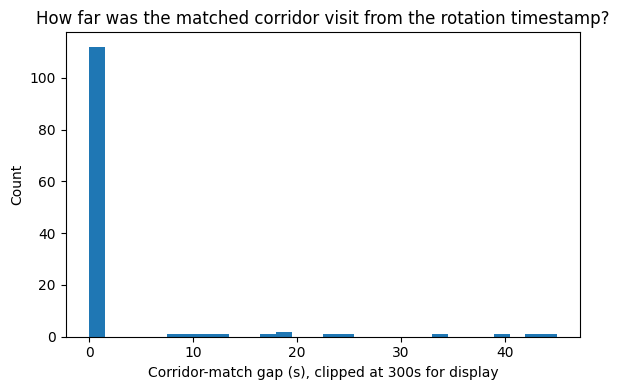

In [9]:
gaps = rotation_table["corridor_match_gap_sec"].dropna()
print(gaps.describe())

n_no_match = rotation_table["corridor_side_at_rotation"].isna().sum()
cutoff_label = "no cutoff (None)" if MAX_CORRIDOR_GAP_SEC is None else f"{MAX_CORRIDOR_GAP_SEC}s cutoff"
print(f"\nRows with no corridor match ({cutoff_label}): {n_no_match} / {len(rotation_table)}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(gaps.clip(upper=300), bins=30)
ax.set_xlabel("Corridor-match gap (s), clipped at 300s for display")
ax.set_ylabel("Count")
ax.set_title("How far was the matched corridor visit from the rotation timestamp?")
plt.tight_layout()
plt.show()


## Check 1: first approach test

For every kage's **test**-phase rotation:
- Does `corridor_side_at_rotation` (where the mouse was when the wheel
  turned) match `first_exploration_side` (which object it explored first)? A match rate well
  above 50% would mean "first approach" is substantially driven by proximity rather than
  novelty.
- Separately: was the mouse's corridor position at rotation already on the side that would
  become **novel**? If `NOR_side` assignment happens to correlate with typical mouse position,
  that's a different (assignment-level) confound worth knowing about too.

In [10]:
test_rows = rotation_table[rotation_table["Phase"] == "test"].dropna(
    subset=["corridor_side_at_rotation", "first_exploration_side"]
).copy()

n = len(test_rows)
match = int((test_rows["corridor_side_at_rotation"] == test_rows["first_exploration_side"]).sum())
print(f"Corridor side at rotation == first-approach side: {match}/{n} = {match/n:.1%}" if n else "No valid test rows.")
if n:
    print("Binomial p-value vs 50%:", binom_test_two_sided(match, n))

def _side_letter(s):
    return {"left": "L", "right": "R"}.get(s)

test_rows["corridor_letter"] = test_rows["corridor_side_at_rotation"].map(_side_letter)
test_rows["was_novel_side"] = test_rows["corridor_letter"] == test_rows["NOR_side"]
n2 = test_rows["was_novel_side"].notna().sum()
novel_n = int(test_rows["was_novel_side"].sum())
print(f"\nCorridor side at rotation == eventual novel side: {novel_n}/{n2} = {novel_n/n2:.1%}" if n2 else "")
if n2:
    print("Binomial p-value vs 50%:", binom_test_two_sided(novel_n, n2))

print()
display_cols = ["Cohort", "KageID", "Genotype", "NOR_side", "corridor_side_at_rotation",
                "corridor_match_gap_sec", "first_exploration_side", "first_exploration_gap_sec"]
test_rows[display_cols]


Corridor side at rotation == first-approach side: 15/25 = 60.0%
Binomial p-value vs 50%: 0.42435622215270996

Corridor side at rotation == eventual novel side: 14/25 = 56.0%
Binomial p-value vs 50%: 0.6900379657745361



,Cohort,KageID,Genotype,NOR_side,corridor_side_at_rotation,corridor_match_gap_sec,first_exploration_side,first_exploration_gap_sec
2,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage1,WT,L,left,22.93,right,136.0
7,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage2,WT,R,left,0.00,right,157.5
12,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage3,RELN-Colbos,L,left,0.00,left,25.0
17,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage4,RELN-Colbos,R,left,0.00,right,13.0
22,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage5,WT,L,left,0.00,left,446.5
27,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage6,WT,R,left,0.00,right,142.0
32,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage7,WT,L,left,0.00,right,28.0
37,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage8,RELN-Colbos,L,right,0.00,left,18.0
42,2025-11-Nov-Dec_RELN-COLBOS_Coh1,Kage9,WT,R,right,0.00,right,254.0
47,2026-01-Jan-Feb_RELN-COLBOS_Coh2,Kage1,RELN-Colbos,R,right,0.00,right,117.0


### Genotype comparisons


In [11]:
test_rows["matched"] = (test_rows["corridor_side_at_rotation"] == test_rows["first_exploration_side"]).astype(int)
by_genotype = test_rows.groupby("Genotype")["matched"].agg(["mean", "count"]).reset_index()
by_genotype


,Genotype,mean,count
0,RELN-Colbos,0.6,10
1,WT,0.6,15


## Check 2: corridor-association test

- This analysis follow the Figure 5C of Ho et al. (2026, *Cell Reports Methods*): using only rotations where
both sides are equally novel or equally familiar (so there's no genuine preference to confound
the measurement). 
- As stated in the paper: "we scored instances where the mice left a corridor and approached
the object on the same side as 0 and the opposite side as 1"

In this example, the sample, ITI baseline and post trial baseline day were taken. On sample day, both objects are novel. 
On ITI baseline and post trial baseline day, both objects are familiar. 

If mice have no positional bias, the corridor association score should have a value around 0.5. A value significantly 
*below* 0.5 means mice tend to stay at the side they were already on.

In [17]:
NEUTRAL_PHASES_ALL_BASELINES = ["sample", "ITI_baseline", "post_trial_baseline"]


def build_corridor_association(rotation_table, phases):
    rows = rotation_table[rotation_table["Phase"].isin(phases)].dropna(
        subset=["corridor_side_at_rotation", "first_exploration_side"]
    ).copy()
    rows["opposite_side_score"] = (
        rows["corridor_side_at_rotation"] != rows["first_exploration_side"]
    ).astype(int)
    by_kage = (
        rows.groupby(["Cohort", "KageID", "Genotype"])["opposite_side_score"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={"mean": "opposite_side_score_mean", "count": "n_rotations"})
    )
    return rows, by_kage


def summarize_corridor_association(rows, label):
    n = len(rows)
    print(f"--- {label} ---")
    if n == 0:
        print("No valid rows.\n")
        return
    mean_score = rows["opposite_side_score"].mean()
    same_n = int((1 - rows["opposite_side_score"]).sum())
    print(f"Corridor-association score (0 = same side, 1 = opposite side), n = {n}")
    print(f"Mean score: {mean_score:.3f}  (same-side rate: {same_n/n:.1%})")
    print("Binomial p-value vs 0.5:", binom_test_two_sided(same_n, n))
    print()


neutral_rows_all_baselines, by_kage_all_baselines = build_corridor_association(rotation_table, NEUTRAL_PHASES_ALL_BASELINES)

summarize_corridor_association(neutral_rows_original, "Original (sample + first ITI_baseline only)")
summarize_corridor_association(neutral_rows_all_baselines, "All baselines (sample + every baseline rotation)")

print("Per-animal scores - all baselines:")
print(by_kage_all_baselines.to_string(index=False))

--- Original (sample + first ITI_baseline only) ---
Corridor-association score (0 = same side, 1 = opposite side), n = 50
Mean score: 0.480  (same-side rate: 52.0%)
Binomial p-value vs 0.5: 0.887724827340783

--- All baselines (sample + every baseline rotation) ---
Corridor-association score (0 = same side, 1 = opposite side), n = 75
Mean score: 0.440  (same-side rate: 56.0%)
Binomial p-value vs 0.5: 0.35569923908148743

Per-animal scores - all baselines:
                          Cohort KageID    Genotype  opposite_side_score_mean  n_rotations
2025-11-Nov-Dec_RELN-COLBOS_Coh1  Kage1          WT                  0.333333            3
2025-11-Nov-Dec_RELN-COLBOS_Coh1  Kage2          WT                  0.000000            3
2025-11-Nov-Dec_RELN-COLBOS_Coh1  Kage3 RELN-Colbos                  0.333333            3
2025-11-Nov-Dec_RELN-COLBOS_Coh1  Kage4 RELN-Colbos                  0.333333            3
2025-11-Nov-Dec_RELN-COLBOS_Coh1  Kage5          WT                  0.666667        

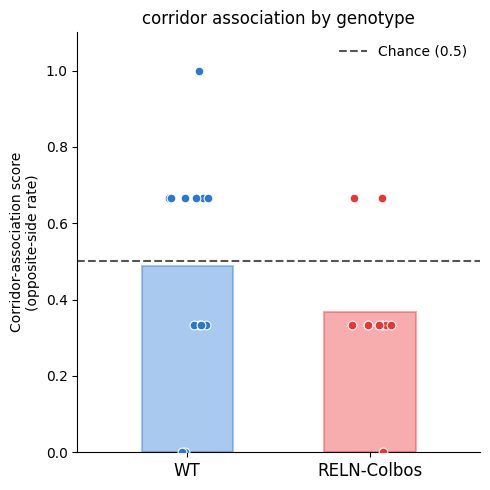

In [25]:
def plot_corridor_association_by_genotype(by_kage, ax, title):
    genotypes = [g for g in ["WT", "RELN-Colbos"] if g in by_kage["Genotype"].values]
    colors = {"WT": "#2a78d6", "RELN-Colbos": "#eb3434"}

    for i, geno in enumerate(genotypes):
        scores = by_kage.loc[by_kage["Genotype"] == geno, "opposite_side_score_mean"].dropna().values
        geno_mean = scores.mean()
        color = colors[geno]

        ax.bar(i, geno_mean, width=0.5, color=color, alpha=0.4,
               edgecolor=color, linewidth=1.5, zorder=1)

        rng = np.random.default_rng(seed=42)
        jitter = rng.uniform(-0.12, 0.12, size=len(scores))
        ax.scatter(np.full(len(scores), i) + jitter, scores,
                   color=color, s=40, zorder=3,
                   edgecolors="white", linewidths=0.8)

    ax.axhline(0.5, color="#555", linestyle="--", linewidth=1.5, label="Chance (0.5)", zorder=2)
    ax.set_xticks(range(len(genotypes)))
    ax.set_xticklabels(genotypes, fontsize=12)
    ax.set_xlim(-0.6, len(genotypes) - 0.4)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Corridor-association score\n(opposite-side rate)")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)


fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plot_corridor_association_by_genotype(by_kage_all_baselines, ax, "corridor association by genotype")
plt.tight_layout()
plt.show()

## Statistics: corridor association score vs. chance

- This follows the statistical approach in Ho et al. (2026): the unit of analysis is the
**per-animal** mean corridor-association score (one number per kage, already computed above),
not the individual rotation - so an animal with many rotations doesn't get more statistical
weight than one with few. 
- For each genotype group, normality of the per-animal scores is checked with a Shapiro-Wilk
test (as in the paper). If normal, a **one-sample Student's t-test** is used to compare the
group's scores against chance (0.5). If not normal, a **one-sample Wilcoxon signed-rank test** is used instead.
- To compare the two genotypes against each other (rather than each against chance
separately), an **independent-samples Student's t-test** is used if both groups' scores are
normally distributed, or a **Mann-Whitney U test** otherwise. This only runs automatically
when there are exactly two genotype groups; edit the cell below if you have more.

Requires `scipy`

In [27]:
from scipy import stats as scipy_stats

def _looks_normal(x, alpha=0.05):
    """Shapiro-Wilk test; returns True if we fail to reject normality (n must be >= 3)."""
    if len(x) < 3:
        return None
    _, p = scipy_stats.shapiro(x)
    return p > alpha


def compute_corridor_stats(by_kage, label):
    vs_chance_rows = []
    for geno in sorted(by_kage["Genotype"].dropna().unique()):
        scores = by_kage.loc[by_kage["Genotype"] == geno, "opposite_side_score_mean"].dropna().to_numpy()
        n = len(scores)
        if n == 0:
            continue
        normal = _looks_normal(scores)
        if normal:
            stat, p = scipy_stats.ttest_1samp(scores, 0.5)
            test_used = "one-sample Student's t-test"
        else:
            diffs = scores - 0.5
            if np.all(diffs == 0) or n < 2:
                stat, p = np.nan, np.nan
                test_used = "one-sample Wilcoxon signed-rank test (insufficient variation)"
            else:
                stat, p = scipy_stats.wilcoxon(diffs)
                test_used = "one-sample Wilcoxon signed-rank test"
        vs_chance_rows.append({
            "Genotype": geno,
            "n_animals": n,
            "mean_score": scores.mean(),
            "sem_score": scores.std(ddof=1) / np.sqrt(n) if n > 1 else np.nan,
            "normal_by_shapiro_wilk": normal,
            "test_vs_chance": test_used,
            "statistic": stat,
            "p_value_vs_chance": p,
        })

    vs_chance_df = pd.DataFrame(vs_chance_rows)
    print(f"--- {label}: each genotype's corridor-association score vs. chance (0.5) ---")
    print(vs_chance_df.to_string(index=False))

    genotypes = sorted(by_kage["Genotype"].dropna().unique())
    between_group_df = pd.DataFrame()
    if len(genotypes) == 2:
        g1, g2 = genotypes
        s1 = by_kage.loc[by_kage["Genotype"] == g1, "opposite_side_score_mean"].dropna().to_numpy()
        s2 = by_kage.loc[by_kage["Genotype"] == g2, "opposite_side_score_mean"].dropna().to_numpy()
        both_normal = bool(_looks_normal(s1)) and bool(_looks_normal(s2))
        if both_normal:
            stat, p = scipy_stats.ttest_ind(s1, s2)
            test_used = "independent-samples Student's t-test"
        else:
            stat, p = scipy_stats.mannwhitneyu(s1, s2, alternative="two-sided")
            test_used = "Mann-Whitney U test"
        between_group_df = pd.DataFrame([{
            "comparison": f"{g1} vs {g2}",
            "n1": len(s1),
            "n2": len(s2),
            "test_used": test_used,
            "statistic": stat,
            "p_value": p,
        }])
        print(f"\n{label}: between-genotype comparison:")
        print(between_group_df.to_string(index=False))
    else:
        print(f"\nFound {len(genotypes)} genotype group(s) {genotypes}; between-group test only auto-runs for exactly two groups.")
    print()
    return vs_chance_df, between_group_df


vs_chance_df_all_baselines, between_group_df_all_baselines = compute_corridor_stats(by_kage_all_baselines, "All baselines")

--- All baselines: each genotype's corridor-association score vs. chance (0.5) ---
   Genotype  n_animals  mean_score  sem_score  normal_by_shapiro_wilk                       test_vs_chance  statistic  p_value_vs_chance
RELN-Colbos         10    0.366667   0.059835                   False one-sample Wilcoxon signed-rank test        3.0           0.007812
         WT         15    0.488889   0.071763                   False one-sample Wilcoxon signed-rank test       42.0           0.298698

All baselines: between-genotype comparison:
       comparison  n1  n2           test_used  statistic  p_value
RELN-Colbos vs WT  10  15 Mann-Whitney U test       53.5 0.204357



## Excel export for plotting

In [28]:
excel_path = OUTPUT_DIR / "corridor_association_score.xlsx"

rotation_level_cols = [
    "Cohort", "KageID", "Genotype", "Phase", "rotation",
    "corridor_side_at_rotation", "corridor_match_gap_sec",
    "first_exploration_side", "first_exploration_gap_sec", "opposite_side_score",
]

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    # Excel sheet names have a hard 31-character limit, hence the short suffixes.
    for suffix, by_kage_x, neutral_rows_x, vs_chance_x, between_group_x in [
        ("allbase", by_kage_all_baselines, neutral_rows_all_baselines, vs_chance_df_all_baselines, between_group_df_all_baselines),
    ]:
        per_animal_sheet = by_kage_x.rename(columns={"opposite_side_score_mean": "CorridorAssociationScore"})
        per_animal_sheet.to_excel(writer, sheet_name=f"Per_animal_score_{suffix}", index=False)
        neutral_rows_x[rotation_level_cols].to_excel(writer, sheet_name=f"Rotation_data_{suffix}", index=False)
        vs_chance_x.to_excel(writer, sheet_name=f"Stats_vs_chance_{suffix}", index=False)
        if not between_group_x.empty:
            between_group_x.to_excel(writer, sheet_name=f"Stats_between_geno_{suffix}", index=False)

print("Saved Excel workbook to:", excel_path)

Saved Excel workbook to: /Volumes/Extreme SSD/NOR_MASTER/corridor_bias_analysis/corridor_association_score.xlsx


## Save outputs

In [29]:
rotation_table.to_csv(OUTPUT_DIR / "corridor_bias_rotation_table.csv", index=False)
by_kage_original.to_csv(OUTPUT_DIR / "corridor_association_score_by_kage_original.csv", index=False)
by_kage_all_baselines.to_csv(OUTPUT_DIR / "corridor_association_score_by_kage_all_baselines.csv", index=False)
test_rows.to_csv(OUTPUT_DIR / "test_phase_corridor_vs_first_approach.csv", index=False)
print("Saved outputs to:", OUTPUT_DIR)

Saved outputs to: /Volumes/Extreme SSD/NOR_MASTER/corridor_bias_analysis
